# Using the MNIST dataset with Kosh

In [1]:
import os
import kosh

# Make sure local file is new sql file
kosh_example_sql_file = "kosh_mnist_example.sql"
if os.path.exists(kosh_example_sql_file):
    os.remove(kosh_example_sql_file)
    
# Create db
kosh.create_new_db(kosh_example_sql_file)

In [2]:
from  kosh import KoshStore, KoshLoader
import os

# connect to store
store = KoshStore(engine="sina", username=os.environ["USER"], sql='sql', db_path=kosh_example_sql_file)

In [3]:
# Add MNST datasets to store
train_img = store.create(name="train10k", metadata={'project':"MNIST"})
train_label = store.create(name="trainlabel10k", metadata={'project':"MNIST"})
test_img = store.create(name="test", metadata={'project':"MNIST"})
test_label = store.create(name="testlabel", metadata={'project':"MNIST"})

In [4]:
# Associate files with datasets
train_img.add_file("../../pytorch_examples/data/raw/t10k-images-idx3-ubyte", mime_type="mnist")
train_label.add_file("../../pytorch_examples/data/raw/t10k-labels-idx1-ubyte", mime_type="mnist")
test_img.add_file("../../pytorch_examples/data/raw/t10k-images-idx3-ubyte", mime_type="mnist")
test_label.add_file("../../pytorch_examples/data/raw/t10k-labels-idx1-ubyte", mime_type="mnist")

In [5]:
import struct
import numpy
        
class MNSTFeature():
    def __init__(self, uri):
        self.uri = uri

    def __getitem__(self, key):
        return self.load_from_mnst(key)

    def __get_slice__(self, start, end):
        out = []
        for i in range(start, end):
            out.append(self.load_from_mnst(i))
        return out

    def load_from_mnst(self, index):
        with open(self.uri, "rb") as f:
            magic, nitems = struct.unpack(">2i", f.read(8))
            if magic == 2051:
                rows, columns = struct.unpack(">ii", f.read(8))
                #print(rows, columns)
                item_size = rows*columns
            else:
                item_size = 1
            offset = item_size*index
            f.seek(offset, 1)
            data = struct.unpack(">{}b".format(item_size), f.read(item_size))
            if magic == 2051:
                data = numpy.array(data)+128
                data.shape = (rows, columns)
        return data

    def get(self, *args, **kargs):
        return self

    def list_features(self):
        with open(self.uri, "rb") as f:
            magic = struct.unpack(">i", f.read(4))[0]
        if magic == 2051:
            return ["image", ]
        else:
            return ["label", ]


class MNSTLoader(KoshLoader):
    def __init__(self, store):
        super(MNSTLoader, self).__init__({"mnist": ["numpy", ]}, store)

    def load(self, Id):
        return self.__store__._load(Id)

    def open(self, Id):
        obj = self.load(Id)
        return MNSTFeature(obj.uri)

    def get(self, feature, *args, **kargs):
        self.open(Id)[feature]        
store.add_loader(MNSTLoader(store))

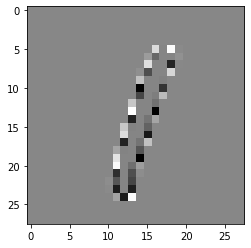

In [6]:
feature = train_img.get("image")
indx = 5
img = feature[indx]
%matplotlib inline
import matplotlib.pyplot as plt
plt.imshow(img, cmap="gray")